In [26]:
# Import all the necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

In [27]:
# Resetando gerador de sequências pseudo-aleatórias de forma que os resultados apresentados sejam sempre os mesmos.
seed = 1234
np.random.seed(seed)

In [28]:
M = 1000

#atributos
x = np.random.uniform(1000,2000,M)
x1 = np.random.uniform(1000,2000,M)

#ruído
w = np.random.normal(0,np.sqrt(10),M)  #Distribuição aleatória gaussiana -> atributos: (media,np.sqrt(variancia),num de elementos)

#target function
y = 1*x + 0.5*x1

# observable function
y_noisy = y + w

print(y_noisy.shape)

(1000,)


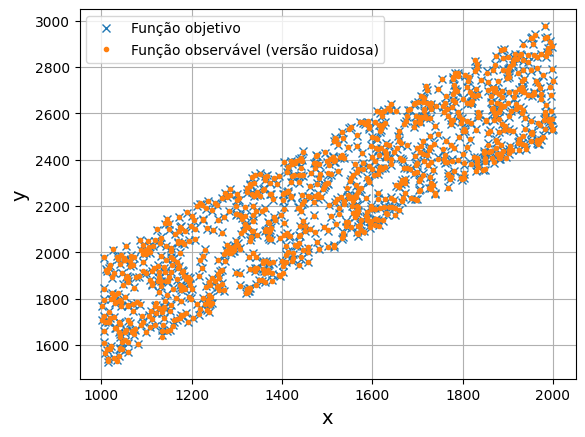

In [29]:
# Comparando a função observável com a objetivo.
fig = plt.figure()
plt.plot(x, y, 'x' , label='Função objetivo')
plt.plot(x, y_noisy, '.', label='Função observável (versão ruidosa)')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [30]:
# np.c_ concatenates vectors.
X = np.c_[np.ones((M, 1)), x, x1] # Precisa colocar todas as ordens da equação, o exemplo tem x e x²


a_numpy = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y_noisy)

# Print best solution.
print('a0: %1.4f' % a_numpy[0])
print('a1: %1.4f' % (a_numpy[1]))
print('a2: %1.4f' % (a_numpy[2]))

a0: -1.0671
a1: 1.0003
a2: 0.5005


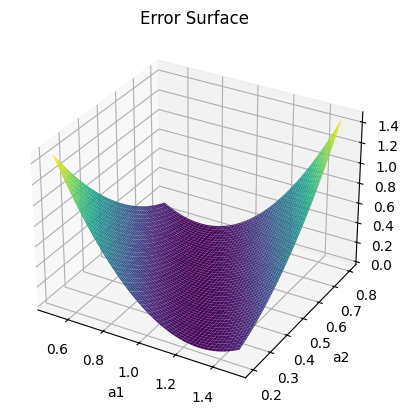

In [31]:
a1_vals = np.linspace(0.5, 1.5, 100)
a2_vals = np.linspace(0.2, 0.8, 100)
a1_grid, a2_grid = np.meshgrid(a1_vals, a2_vals)
# Calculate the error surface
error_surface = np.zeros_like(a1_grid)
for i in range(len(a1_vals)):
    for j in range(len(a2_vals)):
        a = np.array([a1_grid[i,j], a2_grid[i,j]])
        y_pred = a[0] * x + a[1]*x1 # Assuming the model is y = a1 + a2 * x (adjust if different)
        error_surface[i, j] = np.mean((y_noisy - y_pred)**2) # Mean Squared Error

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(a1_grid, a2_grid, error_surface, cmap='viridis')

# Add labels and title
ax.set_xlabel('a1')
ax.set_ylabel('a2')
ax.set_zlabel('Error')
ax.set_title('Error Surface')
plt.show()

a1: 0.9999
a2: 0.5002


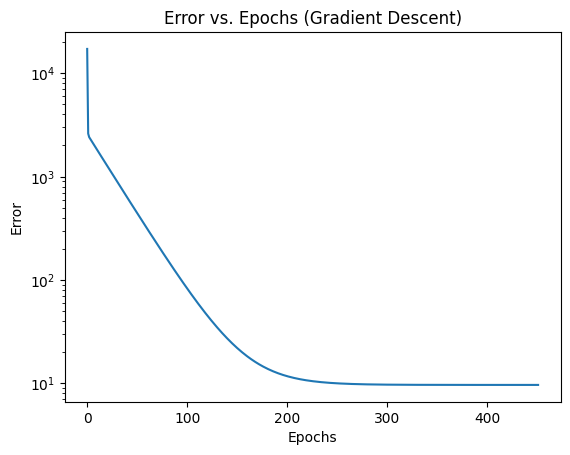

Epochs necessárias para atingir o critério de parada: 451


In [32]:
def gradient_descent(x, x1, y_noisy, learning_rate=0.0000001, max_epochs=1000, tolerance=1e-5):
    a = np.random.rand(2) # iniciar aleatoriamente a1 e a2
    errors = []
    for epoch in range(max_epochs):
        y_pred = a[0] * x + a[1] * x1
        error = np.mean((y_noisy - y_pred)**2)
        errors.append(error)

        # Calculate gradients
        grad_a1 = -2 * np.mean(x * (y_noisy - y_pred))
        grad_a2 = -2 * np.mean(x1 * (y_noisy - y_pred))

        a[0] = a[0] - learning_rate * grad_a1
        a[1] = a[1] - learning_rate * grad_a2

        if epoch > 0 and abs(errors[-1] - errors[-2]) < tolerance:
            break
    return a, errors


a_gd, errors_gd = gradient_descent(x, x1, y_noisy)

print('a1: %1.4f' % (a_gd[0]))
print('a2: %1.4f' % (a_gd[1]))

# Plot the error over epochs
plt.figure()
plt.yscale('log')
plt.plot(errors_gd)
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.title('Error vs. Epochs (Gradient Descent)')
plt.show()


tolerance = 1e-5
for i, error in enumerate(errors_gd):
    if i > 0 and abs(errors_gd[i] - errors_gd[i-1]) < tolerance:
      print("Epochs necessárias para atingir o critério de parada:",i)
      break




Foram necessárias 491 épocas.

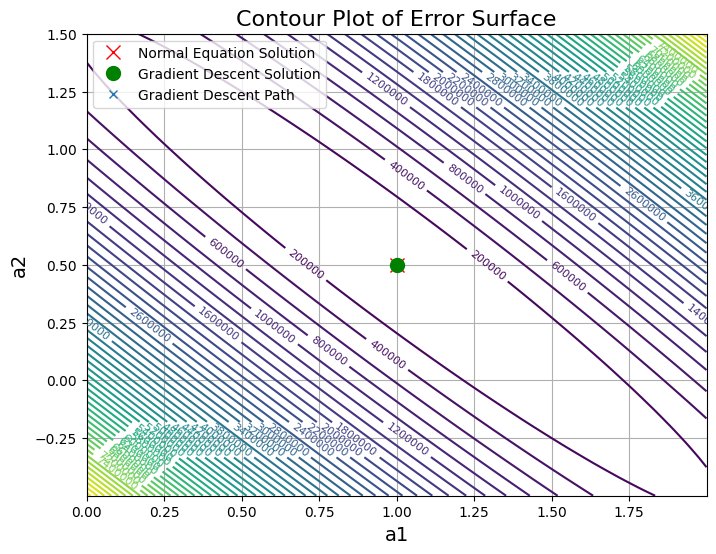

In [33]:
# Calculate the normal equation solution (assuming you have x, x1, and y_noisy defined)
X = np.c_[x, x1]
a_normal = np.linalg.inv(X.T @ X) @ X.T @ y_noisy

# Create the contour plot
a1_min = a_normal[0] - 1
a1_max = a_normal[0] + 1
a2_min = a_normal[1] - 1
a2_max = a_normal[1] + 1

a1_vals = np.linspace(a1_min, a1_max, 100)
a2_vals = np.linspace(a2_min, a2_max, 100)
a1_grid, a2_grid = np.meshgrid(a1_vals, a2_vals)

error_surface = np.zeros_like(a1_grid)
for i in range(len(a1_vals)):
    for j in range(len(a2_vals)):
        a = np.array([a1_grid[i,j], a2_grid[i,j]])
        y_pred = a[0] * x + a[1] * x1
        error_surface[i, j] = np.mean((y_noisy - y_pred)**2)


plt.figure(figsize=(8, 6))
contour = plt.contour(a1_grid, a2_grid, error_surface, 50)  # Increased number of levels for smoother contours
plt.clabel(contour, inline=1, fontsize=8)
plt.plot(a_normal[0], a_normal[1], 'rx', markersize=10, label='Normal Equation Solution')
plt.plot(a_gd[0], a_gd[1], 'go', markersize=10, label='Gradient Descent Solution')

# Initialize history_a to store the values of 'a' during gradient descent
history_a = []

plt.plot([a[0] for a in history_a], [a[1] for a in history_a], 'x', label='Gradient Descent Path')

plt.xlabel('a1', fontsize=14)
plt.ylabel('a2', fontsize=14)
plt.title('Contour Plot of Error Surface', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

#Letra h)
i) Sim, o algoritmo converge para a solução encontrada com a equação normal. Mostrado na figura pelo ponto 'x'.



#Número 2


In [34]:
scaler = StandardScaler()

#Padronização
x_scaled = scaler.fit_transform(x.reshape(-1, 1))
x1_scaled = scaler.fit_transform(x1.reshape(-1,1))

In [39]:
# np.c_ concatenates vectors.
X = np.c_[np.ones((M, 1)), x_scaled, x1_scaled] # Precisa colocar todas as ordens da equação, o exemplo tem x e x²

X_scaled = np.c_[x_scaled.flatten(), x1_scaled.flatten()]

a_numpy_scaled = np.linalg.inv(X_scaled.T.dot(X_scaled)).dot(X_scaled.T).dot(y_noisy)


print('a1 (scaled): %1.4f' % (a_numpy_scaled[0]))
print('a2 (scaled): %1.4f' % (a_numpy_scaled[1]))



a1 (scaled): 294.7894
a2 (scaled): 148.0577
a1 (original): 0.9966
a2 (original): 0.5005


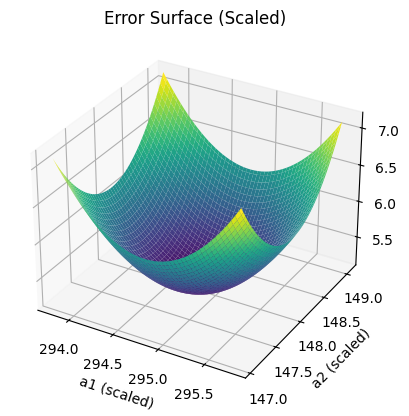

In [40]:
a1_vals = np.linspace(a_numpy_scaled[0]-1, a_numpy_scaled[0]+1, 100)
a2_vals = np.linspace(a_numpy_scaled[1]-1, a_numpy_scaled[1]+1, 100)
a1_grid, a2_grid = np.meshgrid(a1_vals, a2_vals)

# Calculate the error surface using scaled values
error_surface = np.zeros_like(a1_grid)
for i in range(len(a1_vals)):
    for j in range(len(a2_vals)):
        a = np.array([a1_grid[i,j], a2_grid[i,j]])
        y_pred = a[0] * x_scaled.flatten() + a[1] * x1_scaled.flatten() # Usando x_scaled and x1_scaled
        error_surface[i, j] = np.mean((y_noisy - y_pred)**2)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(a1_grid, a2_grid, error_surface, cmap='viridis')

# Add labels and title
ax.set_xlabel('a1 (scaled)')
ax.set_ylabel('a2 (scaled)')
ax.set_zlabel('Error')
ax.set_title('Error Surface (Scaled)')

plt.show()

a1 (scaled): 0.0908
a2 (scaled): 0.0904


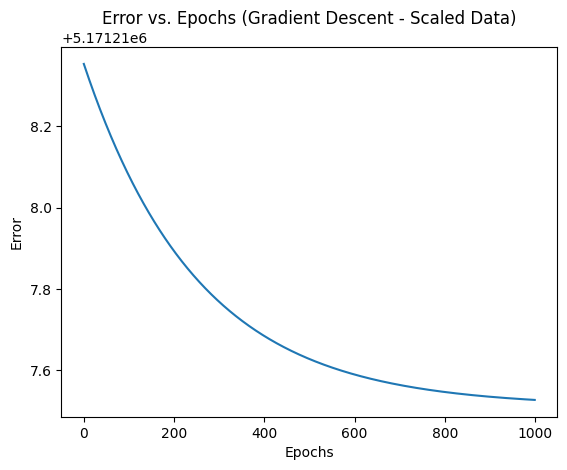

Epochs necessárias para atingir o critério de parada: 451


In [44]:
def gradient_descent(x, x1, y_noisy, learning_rate=0.001, max_epochs=1000, tolerance=1e-5):
    a = np.random.rand(2) # iniciar aleatoriamente a1 e a2
    errors = []
    for epoch in range(max_epochs):
        y_pred = a[0] * x + a[1] * x1
        error = np.mean((y_noisy - y_pred)**2)
        errors.append(error)

        # Calculate gradients
        grad_a1 = -2 * np.mean(x * (y_noisy - y_pred))
        grad_a2 = -2 * np.mean(x1 * (y_noisy - y_pred))

        a[0] = a[0] - learning_rate * grad_a1
        a[1] = a[1] - learning_rate * grad_a2

        if epoch > 0 and abs(errors[-1] - errors[-2]) < tolerance:
            break
    return a, errors

# Execute o gradiente descendente com os dados padronizados
a_gd_scaled, errors_gd_scaled = gradient_descent(x_scaled, x1_scaled, y_noisy, learning_rate=0.001)

print('a1 (scaled): %1.4f' % (a_gd_scaled[0]))
print('a2 (scaled): %1.4f' % (a_gd_scaled[1]))


# Plot the error over epochs for scaled data
plt.figure()
# plt.yscale('log')
plt.plot(errors_gd_scaled)
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.title('Error vs. Epochs (Gradient Descent - Scaled Data)')
plt.show()




tolerance = 1e-5
for i, error in enumerate(errors_gd):
    if i > 0 and abs(errors_gd[i] - errors_gd[i-1]) < tolerance:
      print("Epochs necessárias para atingir o critério de parada:",i)
      break



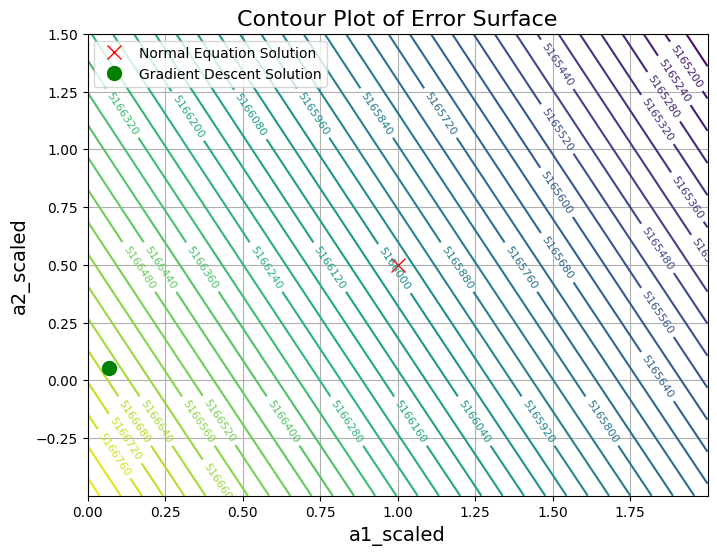

In [55]:
# Matriz X com termo de bias
X_scaled = np.c_[np.ones((M, 1)), x_scaled.flatten(), x1_scaled.flatten()]

# Solução pela equação normal
a_numpy_scaled = np.linalg.inv(X_scaled.T.dot(X_scaled)).dot(X_scaled.T).dot(y_noisy)

# Grid para o contorno
a1_min = a_normal[0] - 1
a1_max = a_normal[0] + 1
a2_min = a_normal[1] - 1
a2_max = a_normal[1] + 1

a1_vals = np.linspace(a1_min, a1_max, 100)
a2_vals = np.linspace(a2_min, a2_max, 100)
a1_grid, a2_grid = np.meshgrid(a1_vals, a2_vals)

# Superfície de erro
error_surface = np.zeros_like(a1_grid)
for i in range(len(a1_vals)):
    for j in range(len(a2_vals)):
        y_pred = a_normal[0] + a1_grid[i,j] * x_scaled.flatten() + a2_grid[i,j] * x1_scaled.flatten()
        error_surface[i, j] = np.mean((y_noisy - y_pred)**2)

# Plot
plt.figure(figsize=(8, 6))
contour = plt.contour(a1_grid, a2_grid, error_surface, 50)
plt.clabel(contour, inline=1, fontsize=8)
plt.plot(a_normal[0], a_normal[1], 'rx', markersize=10, label='Normal Equation Solution')
plt.plot(a_gd_scaled[0], a_gd_scaled[1], 'go', markersize=10, label='Gradient Descent Solution')

plt.xlabel('a1_scaled', fontsize=14)
plt.ylabel('a2_scaled', fontsize=14)
plt.title('Contour Plot of Error Surface', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()


#Número 3
Eu adotaria a padronização porque ela torna a superfície de erro mais simétrica, facilita a convergência do gradiente descendente, garante que todas as variáveis tenham o mesmo peso inicial na otimização e segue boas práticas de modelagem.
No meu entendimento nesse caso não convergiu talvez pelo número de épocas ou pela taxa de aprendizado, talvez mudando isso pode haver um resultado melhor.